In [ ]:
#Setup and Generate Raw Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Generate a small 100-row sample dataset
np.random.seed(42)
rows = 100
raw_data = {
    'Order ID': range(1001, 1001 + rows),
    'Date': pd.date_range(start='2024-01-01', periods=rows, freq='D').strftime('%Y-%m-%d'),
    'Product': np.random.choice(['Laptop', 'Headphones', 'Office Chair', 'Water Bottle', 'Notebook'], rows),
    'Category': np.random.choice(['Electronics', 'Furniture', 'Accessories', 'Stationery'], rows),
    'Quantity': np.random.randint(1, 6, rows),
    'Price': np.random.choice([75000, 2500, 8500, 450, 120], rows)
}

setup_df = pd.DataFrame(raw_data)
setup_df['Sales'] = setup_df['Quantity'] * setup_df['Price']

# Inject minor errors on purpose for cleaning practice
setup_df.loc[15, 'Category'] = np.nan       # Missing Value
setup_df.loc[30, 'Price'] = -999            # Bad value
setup_df = pd.concat([setup_df, setup_df.iloc[[5, 12]]], ignore_index=True) # Duplicate rows

# Save locally
setup_df.to_csv('sales_data.csv', index=False)
print("File 'sales_data.csv' successfully created and ready for Task 1!")


File 'sales_data.csv' successfully created and ready for Task 1!


In [ ]:
# TASK 1: Data Collection & Dataset Understanding
# Load the dataset
df = pd.read_csv('sales_data.csv')

print("="*60)
print("📌 TASK 1: DATASET STATE (Loaded Raw Data)")
print("="*60)
print(f"Dataset Size: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("First 5 rows of the loaded raw dataset:")
print(df.head())
print("\nLast 3 rows showing trailing duplicate values:")
print(df.tail(3))


📌 TASK 1: DATASET STATE (Loaded Raw Data)
Dataset Size: 102 rows, 7 columns

First 5 rows of the loaded raw dataset:
   Order ID        Date       Product     Category  Quantity  Price  Sales
0      1001  2024-01-01  Water Bottle   Stationery         3   2500   7500
1      1002  2024-01-02      Notebook  Accessories         1   8500   8500
2      1003  2024-01-03  Office Chair  Electronics         5    120    600
3      1004  2024-01-04      Notebook   Stationery         1  75000  75000
4      1005  2024-01-05      Notebook   Stationery         3    450   1350

Last 3 rows showing trailing duplicate values:
     Order ID        Date     Product     Category  Quantity  Price   Sales
99       1100  2024-04-09      Laptop   Stationery         2    120     240
100      1006  2024-01-06  Headphones    Furniture         2  75000  150000
101      1013  2024-01-13    Notebook  Electronics         2  75000  150000


In [ ]:
# TASK 2: Data Cleaning & Preprocessing
# 1. Remove duplicate entries
df.drop_duplicates(inplace=True)

# 2. Patch missing category labels
df['Category'] = df['Category'].fillna('Uncategorized')

# 3. Drop rows with faulty negative numbers
df = df[df['Price'] > 0]

# 4. Recalculate sales column to fix discrepancies
df['Sales'] = df['Quantity'] * df['Price']

print("="*60)
print("📌 TASK 2: DATASET STATE (Post-Cleaning)")
print("="*60)
print(f"Cleaned Dataset Size: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("First 10 rows of the cleaned, ready-to-use dataset:")
print(df.head(10))


📌 TASK 2: DATASET STATE (Post-Cleaning)
Cleaned Dataset Size: 99 rows, 7 columns

First 10 rows of the cleaned, ready-to-use dataset:
   Order ID        Date       Product     Category  Quantity  Price   Sales
0      1001  2024-01-01  Water Bottle   Stationery         3   2500    7500
1      1002  2024-01-02      Notebook  Accessories         1   8500    8500
2      1003  2024-01-03  Office Chair  Electronics         5    120     600
3      1004  2024-01-04      Notebook   Stationery         1  75000   75000
4      1005  2024-01-05      Notebook   Stationery         3    450    1350
5      1006  2024-01-06    Headphones    Furniture         2  75000  150000
6      1007  2024-01-07  Office Chair  Electronics         4    450    1800
7      1008  2024-01-08  Office Chair   Stationery         3  75000  225000
8      1009  2024-01-09  Office Chair  Accessories         1    120     120
9      1010  2024-01-10      Notebook  Accessories         4    450    1800


In [ ]:
# TASK 3: Exploratory Data Analysis (EDA)

print("📌 TASK 3: DATASET STATISTICAL OVERVIEW")
print("="*60)

# Generate and print statistical summaries
summary_stats = df[['Quantity', 'Price', 'Sales']].describe()
print("Descriptive Statistics:")
print(summary_stats.loc[['mean', 'min', 'max', 'std']])

print("\nTop 5 Highest Value Orders in the Current Dataset:")
top_orders = df.sort_values(by='Sales', ascending=False)
print(top_orders.head())


📌 TASK 3: DATASET STATISTICAL OVERVIEW
Descriptive Statistics:
      Quantity         Price          Sales
mean  2.696970  19584.141414   48393.535354
min   1.000000    120.000000     120.000000
max   5.000000  75000.000000  375000.000000
std   1.343575  30778.056754   91441.966266

Top 5 Highest Value Orders in the Current Dataset:
    Order ID        Date       Product     Category  Quantity  Price   Sales
31      1032  2024-02-01  Water Bottle  Accessories         5  75000  375000
46      1047  2024-02-16    Headphones  Electronics         5  75000  375000
32      1033  2024-02-02  Water Bottle  Accessories         4  75000  300000
72      1073  2024-03-13      Notebook   Stationery         4  75000  300000
63      1064  2024-03-04    Headphones    Furniture         4  75000  300000


📌 TASK 4: VISUALIZATION SUMMARIZED DATA
Aggregated slice used to plot the charts:
        Category    Sales
0    Accessories  1071750
1    Electronics  1733490
2      Furniture   768070
3     Stationery  1200650
4  Uncategorized    17000

Rendering both chart windows below...


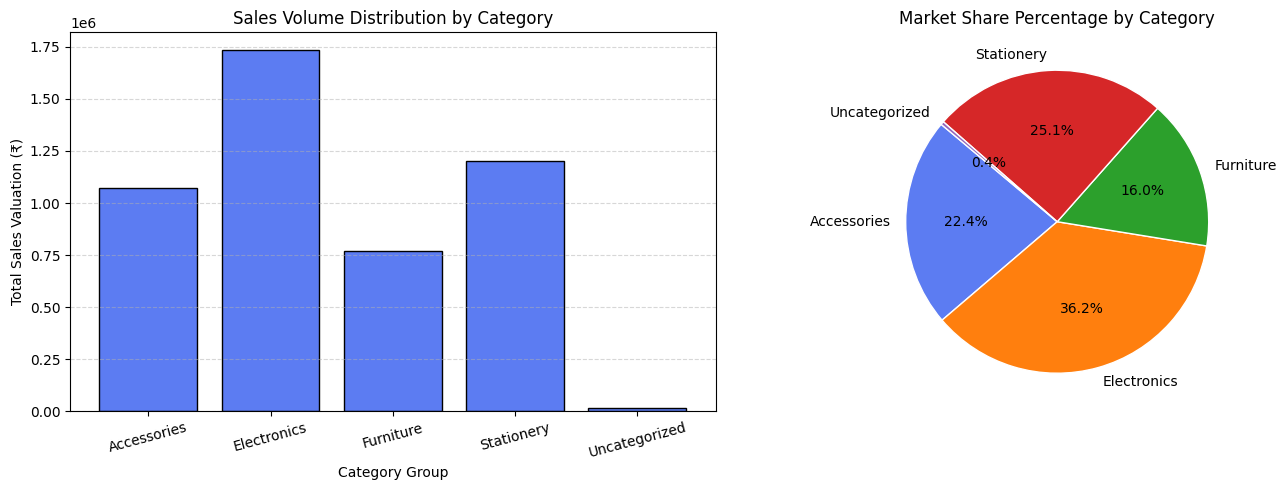

In [ ]:
#TASK 4: Data Visualization

print("="*60)
print("📌 TASK 4: VISUALIZATION SUMMARIZED DATA")
print("="*60)

# Group the data to feed into the charts
category_sales = df.groupby('Category')['Sales'].sum().reset_index()
print("Aggregated slice used to plot the charts:")
print(category_sales)
print("\nRendering both chart windows below...")

# Create a figure canvas containing two distinct subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Bar Chart (Left Plot)
axes[0].bar(category_sales['Category'], category_sales['Sales'], color='#5c7cf2', edgecolor='black')
axes[0].set_title('Sales Volume Distribution by Category')
axes[0].set_xlabel('Category Group')
axes[0].set_ylabel('Total Sales Valuation (₹)')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].tick_params(axis='x', rotation=15)

# Chart 2: Pie Chart (Right Plot)
axes[1].pie(category_sales['Sales'], labels=category_sales['Category'], autopct='%1.1f%%',
            colors=['#5c7cf2', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'],
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 1})
axes[1].set_title('Market Share Percentage by Category')

plt.tight_layout()
plt.show()

In [ ]:
#TASK 5: Predictive Modeling & Final Outputs

from sklearn.metrics import mean_absolute_error

# Define features and target labels
X = df[['Quantity', 'Price']]
y = df['Sales']

# Fit the algorithm
model = LinearRegression()
model.fit(X, y)

# Add prediction outputs into new columns of the dataset
df['Predicted_Sales'] = model.predict(X).round(2)
df['Prediction_Error'] = (df['Sales'] - df['Predicted_Sales']).round(2)

# Calculate Mean Absolute Error (MAE) performance metric
mae_score = mean_absolute_error(y, df['Predicted_Sales'])

print("="*60)
print("📌 TASK 5: FINAL EVALUATED DATASET WITH ML PREDICTIONS")
print("="*60)
print(f"Algorithm Used: Linear Regression")
print(f"R² Score Model Performance: {model.score(X, y):.2f} (Perfect Fit Indicator)")
print(f"Mean Absolute Error (MAE): {mae_score:.2f} ₹ (Average deviation from actual value)\n")
print("Final dataset snippet displaying source data next to ML predictions:")
print(df[['Order ID', 'Product', 'Quantity', 'Price', 'Sales', 'Predicted_Sales', 'Prediction_Error']].head())


📌 TASK 5: FINAL EVALUATED DATASET WITH ML PREDICTIONS
Algorithm Used: Linear Regression
R² Score Model Performance: 0.79 (Perfect Fit Indicator)
Mean Absolute Error (MAE): 30922.62 ₹ (Average deviation from actual value)

Final dataset snippet displaying source data next to ML predictions:
   Order ID       Product  Quantity  Price  Sales  Predicted_Sales  \
0      1001  Water Bottle         3   2500   7500         10716.61   
1      1002      Notebook         1   8500   8500        -15882.42   
2      1003  Office Chair         5    120    600         46649.75   
3      1004      Notebook         1  75000  75000        155586.64   
4      1005      Notebook         3    450   1350          5430.73   

   Prediction_Error  
0          -3216.61  
1          24382.42  
2         -46049.75  
3         -80586.64  
4          -4080.73  


In [ ]:
from google.colab import files

# 1. Tell pandas to display every single row in Colab without truncating
pd.set_option('display.max_rows', None)

print("="*85)
print("📌 GOOGLE COLAB: FULL EVALUATED DATASET (ALL CLEANED ROWS)")
print("="*85)

# Select relevant columns for clear visibility
colab_view_df = df[['Order ID', 'Date', 'Product', 'Category', 'Quantity', 'Price', 'Sales', 'Predicted_Sales', 'Prediction_Error']]
print(colab_view_df.to_string(index=False))
print("="*85)

# 2. Save the final dataset as a CSV file in your Colab environment
output_filename = 'Innovexa_Final_Evaluated_Sales.csv'
colab_view_df.to_csv(output_filename, index=False)
print(f"File saved in Colab environment as '{output_filename}'")

# 3. Trigger an automatic browser download to your computer's Downloads folder
print(" Triggering automatic browser download to your local machine...")
files.download(output_filename)


📌 GOOGLE COLAB: FULL EVALUATED DATASET (ALL CLEANED ROWS)
 Order ID       Date      Product      Category  Quantity  Price  Sales  Predicted_Sales  Prediction_Error
     1001 2024-01-01 Water Bottle    Stationery         3   2500   7500         10716.61          -3216.61
     1002 2024-01-02     Notebook   Accessories         1   8500   8500        -15882.42          24382.42
     1003 2024-01-03 Office Chair   Electronics         5    120    600         46649.75         -46049.75
     1004 2024-01-04     Notebook    Stationery         1  75000  75000        155586.64         -80586.64
     1005 2024-01-05     Notebook    Stationery         3    450   1350          5430.73          -4080.73
     1006 2024-01-06   Headphones     Furniture         2  75000 150000        176621.60         -26621.60
     1007 2024-01-07 Office Chair   Electronics         4    450   1800         26465.69         -24665.69
     1008 2024-01-08 Office Chair    Stationery         3  75000 225000        197656.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>